In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
import hyperopt
import sys
sys.path.append('../spock/')
try:
    plt.style.use('paper')
except:
    pass
%matplotlib inline

Load the models

In [3]:
# #load datapath for clean training data that is generated
datapath = '../training_data/dataset/resonant/'
data = pd.read_csv(datapath + 'dRatio_data2.csv')
# data = pd.read_csv(datapath + '5-19-25-massOrder.csv')
# data = pd.read_csv(datapath + '5-22-25-3BRfill.csv')


# #remove junk columns
data = data.drop(columns=['Unnamed: 0','Unnamed: 0.1'])

In [4]:
data.head()

,EMcrossMax,EMfracstdMax,EPstdMax,MMRstrengthMax,conjunctionMagMax,relConjunctionMagMax,dRatioMax,EMcrossMin,EMfracstdMin,EPstdMin,...,massOrder,threeBRfillfac,Tsec,2BRfillMax,2BRfillMin,InitialStable,runstring,instability_time,shadow_instability_time,Stable
0,0.060234,0.029447,0.001995,0.498040,0.419620,0.984614,0.069938,0.504063,0.002900,0.000816,...,1.461553,1.917395,28431.355594,3.511391,0.019403,1.0,0000000.bin,1.545872e+06,3.063700e+06,False
1,0.080547,0.016559,0.000112,0.452015,0.870643,0.876273,0.104899,0.240504,0.006736,0.001621,...,1.822340,0.407998,3904.311701,6.141465,0.016753,1.0,0000001.bin,9.990000e+08,9.990000e+08,True
2,1.001981,0.001402,0.003742,0.010415,0.003887,0.003748,21.202906,0.129660,0.028844,0.003181,...,0.000000,0.418203,70073.695993,NaN,0.560341,1.0,0000002.bin,9.990000e+08,9.990000e+08,True
3,0.406112,0.036478,0.002390,0.321071,0.029696,0.107787,0.326652,0.427768,0.036219,0.008587,...,1.144375,0.122730,18313.684674,0.031144,0.056491,1.0,0000003.bin,2.287671e+06,8.392234e+06,False
4,0.059897,0.028009,0.001623,0.341814,0.385420,0.986495,0.101904,0.257596,0.053197,0.001287,...,0.109704,2.369149,4110.203941,1.570352,0.148015,1.0,0000004.bin,9.668931e+05,3.380350e+05,False


In [4]:
import matplotlib as mpl

In [6]:
data.columns

Index(['EMcrossMax', 'EMfracstdMax', 'EPstdMax', 'MMRstrengthMax',
       'conjunctionMagMax', 'relConjunctionMagMax', 'dRatioMax', 'EMcrossMin',
       'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin', 'conjunctionMagMin',
       'relConjunctionMagMin', 'dRatioMin', 'MEGNO', 'MEGNOstd', 'massOrder',
       'threeBRfillfac', 'Tsec', '2BRfillMax', '2BRfillMin', 'InitialStable',
       'runstring', 'instability_time', 'shadow_instability_time', 'Stable'],
      dtype='object')

add column taking the max of the two diff conjunction angle methods to see if we can reduce feature dimension without decreasing performance, currently the two methods are not consistent so you can not.... this seems like something that would be good to resolve

In [7]:
data['magMax'] = np.max([data['conjunctionMagMax'], data['relConjunctionMagMax']])
data['magMin'] = np.max([data['conjunctionMagMin'], data['relConjunctionMagMin']])

Make feature list to test threeBR importance

In [7]:

featuresThree = ['EMcrossMax', 'EMfracstdMax', 'EPstdMax',
       'MMRstrengthMax', 'conjunctionMagMax', 'relConjunctionMagMax',
       'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd',
       'massOrder',  'Tsec', '2BRfillMax', '2BRfillMin', 'threeBRfillfac']
features = ['EMcrossMax', 'EMfracstdMax', 'EPstdMax',
       'MMRstrengthMax', 'conjunctionMagMax', 'relConjunctionMagMax',
       'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd',
       'massOrder',  'Tsec', '2BRfillMax', '2BRfillMin']

Make feature list to test width importance

In [4]:
featuresStrengthWidth = ['EMcrossMax', 'EMfracstdMax', 'EPstdMax',
       'MMRstrengthMax', 'conjunctionMagMax', 'relConjunctionMagMax',
       'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd',
       'massOrder',  'Tsec', '2BRfillMax', '2BRfillMin', 'dRatioMax', 'dRatioMin']
featuresWidth = ['EMcrossMax', 'EMfracstdMax', 'EPstdMax', 'conjunctionMagMax', 
       'relConjunctionMagMax', 'EMcrossMin', 'EMfracstdMin', 'EPstdMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd',
       'massOrder',  'Tsec', '2BRfillMax', '2BRfillMin', 'dRatioMax', 'dRatioMin']
features = ['EMcrossMax', 'EMfracstdMax', 'EPstdMax',
       'MMRstrengthMax', 'conjunctionMagMax', 'relConjunctionMagMax',
       'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin',
       'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd',
       'massOrder',  'Tsec', '2BRfillMax', '2BRfillMin']

In [5]:
def train_test(dataset,features):
    '''divides the dataset into 80% training and 20% testing and returns training/testing sets'''
    Nrows = int(0.8*dataset.shape[0])
    train = dataset.iloc[:Nrows, :]
    test = dataset.iloc[Nrows:, :]
    #remove testing systems that go unstable in 1e4 orbits

    test = test.drop(test[test['InitialStable']==False].index)
    return train[features], train['Stable'], test[features], test['Stable']

In [6]:

trainX, trainY, testX, testY = train_test(data, featuresStrengthWidth)

In [10]:
print(features)

['EMcrossMax', 'EMfracstdMax', 'EPstdMax', 'MMRstrengthMax', 'conjunctionMagMax', 'relConjunctionMagMax', 'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'MMRstrengthMin', 'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd', 'massOrder', 'Tsec', '2BRfillMax', '2BRfillMin']


In [66]:
print(featuresWidth)

['EMcrossMax', 'EMfracstdMax', 'EPstdMax', 'conjunctionMagMax', 'relConjunctionMagMax', 'EMcrossMin', 'EMfracstdMin', 'EPstdMin', 'conjunctionMagMin', 'relConjunctionMagMin', 'MEGNO', 'MEGNOstd', 'massOrder', 'Tsec', '2BRfillMax', '2BRfillMin', 'dRatioMax', 'dRatioMin']


In [13]:
trainX, trainY, testX, testY = train_test(data, featuresWidth)

In [7]:
from sklearn import metrics
from sklearn.metrics import roc_curve, confusion_matrix, auc
def ROC_curve( model, x,y):
    preds = model.predict_proba(x)[:,1]
    fpr, tpr, ROCthresholds = roc_curve(y, preds)
    roc_auc = metrics.roc_auc_score(y, preds)
    return roc_auc, fpr, tpr, ROCthresholds

In [8]:
model = XGBClassifier(learning_rate = 0.05, 
                         max_depth = 15, 
                         subsample = 0.95,
                         min_child_weight = 5,
                         n_estimators = 200,
                         )

In [9]:
model.fit(trainX,trainY)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=15, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

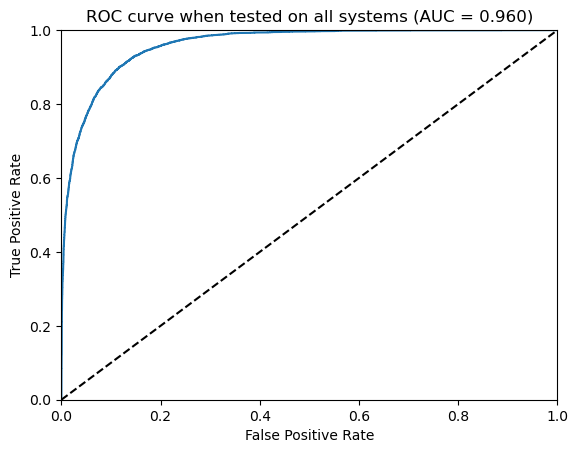

In [10]:
roc_auc, fpr, tpr, ROCthresholds = ROC_curve(model, testX, testY)

fig, ax = plt.subplots()
ax.plot(fpr, tpr)
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curve when tested on all systems (AUC = {0:.3f})'.format(roc_auc))
plt.show()


In [102]:
roc_auc

0.9604324909063018

In [74]:
data.tail()

,EMcrossMax,EMfracstdMax,EPstdMax,MMRstrengthMax,conjunctionMagMax,relConjunctionMagMax,dRatioMax,EMcrossMin,EMfracstdMin,EPstdMin,...,massOrder,threeBRfillfac,Tsec,2BRfillMax,2BRfillMin,InitialStable,runstring,instability_time,shadow_instability_time,Stable
102492,0.089252,NaN,NaN,NaN,0.119731,0.062516,NaN,0.310694,NaN,NaN,...,1.499451,NaN,23579.372334,0.936357,0.032253,0.0,9044761.bin,6.303165e+04,6.470086e+04,False
102493,0.082222,0.039388,0.006138,0.680735,0.365947,0.990173,0.069768,0.664222,0.031006,0.001013,...,1.597352,3.802285,4127.353879,1.517855,NaN,1.0,9045377.bin,6.990387e+05,8.267916e+05,False
102494,0.131799,0.022057,0.000146,0.840640,0.454718,0.991491,0.088282,0.366664,0.060791,0.016575,...,1.640365,0.543637,1130.303709,1.149952,0.033339,1.0,9045380.bin,1.193822e+07,3.363291e+07,False
102495,0.209454,0.036889,0.005252,1.497917,0.855549,0.888376,0.079787,0.395073,0.102246,0.022792,...,1.437117,0.118894,4234.297102,1.770775,0.074401,1.0,9045382.bin,2.064407e+08,4.316851e+07,False
102496,0.430482,NaN,NaN,NaN,0.024608,0.017209,NaN,0.182523,NaN,NaN,...,0.287606,NaN,12025.697898,0.355262,0.080726,0.0,9045383.bin,2.266066e+04,2.228425e+04,False


Identify inconstant systems where the two conjunction angle calculations don't match
Our current understanding indicates sometimes the rel calculation wont detect a resonance, but the not rel calc should always find one IF the rel one finds a resonance, this is not the case however....

Make a graph to determine which value is the cut off for which population is resonant or not.

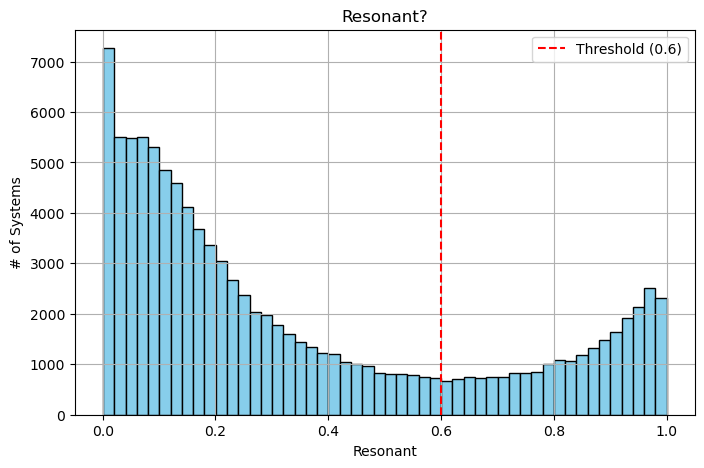

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data['conjunctionMagMax'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(0.6, color='red', linestyle='--', label='Threshold (0.6)')
plt.xlabel('Resonant')
plt.ylabel('# of Systems')
plt.title('Resonant?')
plt.legend()
plt.grid(True)
plt.show()

So, the cut off for resonant values would be 0.6. 

In [11]:
nonres = ((data['conjunctionMagMax'] < 0.6) & (data['relConjunctionMagMax'] < 0.6))

In [ ]:
nonres = (nonres & (data['dRatioMax']>1) & (data['dRatioMin']>1))

In [14]:
unstable = (data['2BRfillMax']>1)

In [12]:
data[nonres]['Stable'].describe()

count     62618
unique        2
top       False
freq      53231
Name: Stable, dtype: object

In [15]:
data[unstable]['Stable'].describe()

count     34933
unique        2
top       False
freq      29681
Name: Stable, dtype: object

In [13]:
# nonres
53231/62618

0.8500910281388738

In [18]:
# with dRatio
2649/2679

0.9888017917133258

In [21]:
# data[ind][['conjunctionMagMax','relConjunctionMagMax', 'conjunctionMagMin','relConjunctionMagMin']].to_csv('conjunctionAng.csv', index=True, index_label='FileNum')

In [60]:
data[ind][['conjunctionMagMax','relConjunctionMagMax', 'conjunctionMagMin','relConjunctionMagMin']]

,conjunctionMagMax,relConjunctionMagMax,conjunctionMagMin,relConjunctionMagMin
5,0.608141,0.743475,0.002970,0.010634
7,0.211127,0.080899,0.316681,0.155011
222,0.265644,0.258529,0.522788,0.250675
303,0.154858,0.150250,0.110303,0.112125
386,0.727688,0.731490,0.260871,0.264737
...,...,...,...,...
102360,0.074719,0.120386,0.049080,0.047137
102381,0.191497,0.098263,0.256011,0.232085
102462,0.227160,0.113886,0.104634,0.068675
102467,0.156110,0.095436,0.097483,0.178448


In [77]:
data[['dRatioMax','dRatioMin', 'MMRstrengthMax', 'MMRstrengthMin']]

,dRatioMax,dRatioMin,MMRstrengthMax,MMRstrengthMin
0,0.069938,NaN,0.498040,NaN
1,0.104899,13.611439,0.452015,0.008674
2,21.202906,0.074083,0.010415,1.001973
3,0.326652,7.962116,0.321071,0.012958
4,0.101904,2.019461,0.341814,0.034789
...,...,...,...,...
102492,NaN,NaN,NaN,NaN
102493,0.069768,NaN,0.680735,NaN
102494,0.088282,21.013984,0.840640,0.005149
102495,0.079787,3.559753,1.497917,0.029719


In [28]:
print(data.loc[data['dRatioMax'].idxmin()])

EMcrossMax                      0.211419
EMfracstdMax                    0.007902
EPstdMax                        0.001431
MMRstrengthMax                 60.931152
conjunctionMagMax               0.999111
relConjunctionMagMax            0.999926
dRatioMax                       0.001961
EMcrossMin                      0.288638
EMfracstdMin                    0.016245
EPstdMin                        0.004568
MMRstrengthMin                  0.006778
conjunctionMagMin               0.001592
relConjunctionMagMin            0.000521
dRatioMin                      25.634091
MEGNO                           2.000515
MEGNOstd                        0.000643
massOrder                       1.387996
threeBRfillfac                  0.011676
Tsec                       193969.411332
2BRfillMax                      0.198708
2BRfillMin                      0.007402
InitialStable                        1.0
runstring                    4233534.bin
instability_time            1000000000.0
shadow_instabili

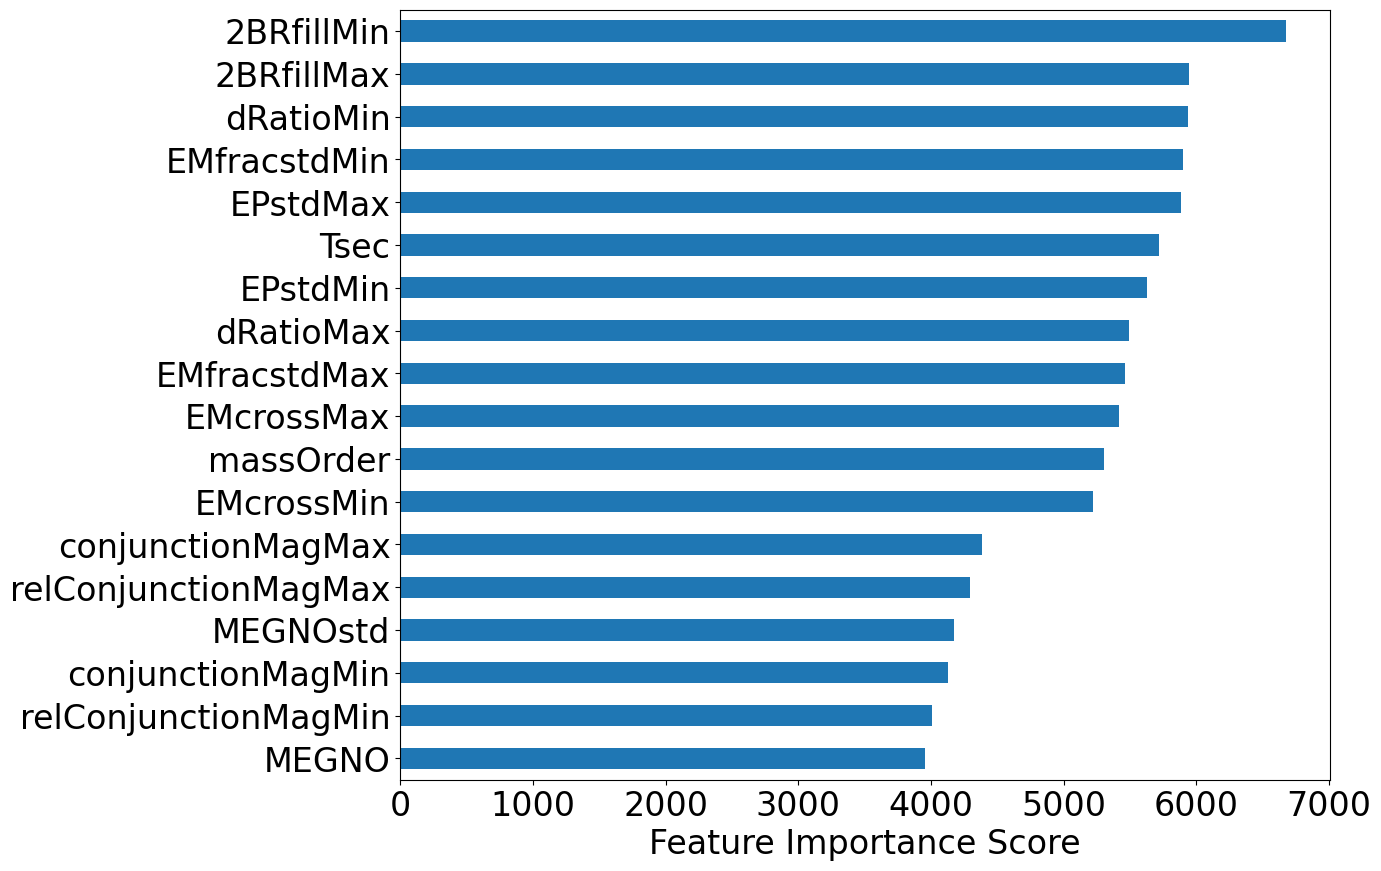

In [29]:
feat_imp = pd.Series(model.get_booster().get_fscore()).sort_values(ascending=False)
ax = feat_imp.plot.barh(figsize=(12,10), fontsize=24)
ax.set_xlabel('Feature Importance Score', fontsize=24)
ax.invert_yaxis()
plt.show()

Testing function

In [105]:
def findAUC(features):
    trainX, trainY, testX, testY = train_test(data, featuresStrengthWidth)

    model = XGBClassifier(learning_rate = 0.05, 
                         max_depth = 15, 
                         subsample = 0.95,
                         min_child_weight = 5,
                         n_estimators = 200,
                         )
    model.fit(trainX,trainY)
    roc_auc, fpr, tpr, ROCthresholds = ROC_curve(model, testX, testY)
    return roc_auc

Test 3BRfill

In [106]:
findAUC(featuresWidth)

0.9604324909063018

In [107]:
findAUC(featuresStrengthWidth)


0.9604324909063018

Seems to not make a large diff at all and might be redundant 

Demonstration of potential ablation study

In [39]:
len(featuresWidth)

20

In [33]:
for i in range(len(featuresWidth)):
    print(i,f'Not {featuresWidth[i]}', findAUC(featuresWidth[:i] + featuresWidth[i+1:]))

0 Not EMcrossMax 0.9595450381098151
1 Not EMfracstdMax 0.9560563060840396
2 Not EPstdMax 0.9589160082969652
3 Not MMRstrengthMax 0.9594167834716806
4 Not conjunctionMagMax 0.9597916743957974
5 Not relConjunctionMagMax 0.9597895287238994
6 Not EMcrossMin 0.959177860006304
7 Not EMfracstdMin 0.9577145480164618
8 Not EPstdMin 0.9585413348395949
9 Not MMRstrengthMin 0.9599205306919301
10 Not conjunctionMagMin 0.9603435180114586
11 Not relConjunctionMagMin 0.9602659331252351
12 Not MEGNO 0.9601337060945332
13 Not MEGNOstd 0.9600808036840258
14 Not massOrder 0.9587619838493825
15 Not Tsec 0.9579680417538472
16 Not 2BRfillMax 0.9579658815841665
17 Not 2BRfillMin 0.9583182067088982
18 Not dRatioMax 0.9594141811196152
19 Not dRatioMin 0.9597245569089673


The reason why sometimes it does better when you remove features is since the complexity of the model is limited, so if the info is already redundant, forcing more features can be less effective (your not actually forcing the features)

This effect can be negated by allowing for more depth and more estimators